# 03 - XGBoost Classifier: Term Deposit Subscription Prediction

This notebook is the third stage of the project, following:

- **01_EDA.ipynb** - exploratory data analysis
- **02_Logistic_Regression.ipynb** - WoE/IV based logistic regression with regularization

Here we build a **gradient boosted tree model using XGBoost**. Unlike logistic regression, tree-based
models do not need linear-model preprocessing such as Weight of Evidence encoding, feature scaling, or
strict linearity assumptions. Instead, they can capture non-linear relationships and interactions
between features automatically.

### What this notebook covers, end to end

1. Recap of preprocessing decisions carried over from notebooks 01/02
2. Feature encoding suited for tree-based models
3. XGBoost fundamentals (what boosting is doing, and what each hyperparameter controls)
4. A **baseline model** to expose the false-negative problem caused by class imbalance
5. **5-fold Stratified Cross-Validation with Grid Search** for hyperparameter tuning
6. Model evaluation with a full suite of metrics (confusion matrix, ROC-AUC, PR-AUC, KS, decile/lift table)
7. **Threshold tuning that explicitly targets a reduction in False Negatives** - because in this
   business problem, a False Negative means we predicted a customer would *not* subscribe to a term
   deposit when they actually *would have* - a missed sales opportunity that costs the bank real revenue.
8. Feature importance (gain/weight/cover, permutation importance, and SHAP)
9. Final model training on the full training data, prediction on `test.csv`, and scoring against
   `solution_checker.xlsx`
10. Comparison against the Logistic Regression baseline from notebook 02

### Why "reduce false negatives" matters here

The target is imbalanced: roughly 12% of customers in the training data subscribed ("yes"), and 88%
did not ("no"). A model that is not corrected for this imbalance can achieve high overall accuracy by
simply predicting "no" most of the time - but that means it will miss a large fraction of the actual
subscribers (high False Negatives, low Recall on the "yes" class). Since the business cost of missing a
genuine subscriber is normally higher than the cost of an extra phone call to a customer who declines,
we will deliberately tune the model to push Recall on the "yes" class up, and we will measure the effect
this has on the confusion matrix directly.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import time

# Modelling
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)
from scipy.stats import ks_2samp

# Interpretability
from sklearn.inspection import permutation_importance
import shap

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display / warnings
pd.set_option('display.max_columns', 100)
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_style('whitegrid')


## 1. Load Data

We load the same `train.csv`, `test.csv`, and `solution_checker.xlsx` used in notebooks 01 and 02.

- `train.csv` has the `subscribed` target column (31,647 rows).
- `test.csv` has no target column (13,564 rows) - these are the rows we must predict.
- `solution_checker.xlsx` (Sheet2) contains the true labels for `test.csv`, in the same row order as
  `test.csv`. This lets us score our final test-set predictions directly, exactly as done in notebook 02.


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('train shape:', train.shape)
print('test shape :', test.shape)

train.head()


train shape: (31647, 18)
test shape : (13564, 17)


,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,26110,56,admin.,married,unknown,no,1933,no,no,telephone,19,nov,44,2,-1,0,unknown,no
1,40576,31,unknown,married,secondary,no,3,no,no,cellular,20,jul,91,2,-1,0,unknown,no
2,15320,27,services,married,secondary,no,891,yes,no,cellular,18,jul,240,1,-1,0,unknown,no
3,43962,57,management,divorced,tertiary,no,3287,no,no,cellular,22,jun,867,1,84,3,success,yes
4,29842,31,technician,married,secondary,no,119,yes,no,cellular,4,feb,380,1,-1,0,unknown,no


Class counts:
 subscribed_bin
0    27932
1     3715
Name: count, dtype: int64

Class percentage:
 subscribed_bin
0    88.26
1    11.74
Name: proportion, dtype: float64


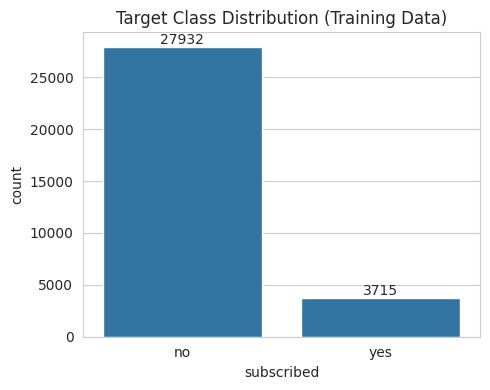

In [3]:
# Binary target: 1 = subscribed ("yes"), 0 = did not subscribe ("no")
train['subscribed_bin'] = (train['subscribed'] == 'yes').astype(int)

class_counts = train['subscribed_bin'].value_counts()
class_pct = train['subscribed_bin'].value_counts(normalize=True) * 100
print('Class counts:\n', class_counts)
print('\nClass percentage:\n', class_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='subscribed', data=train, ax=ax, order=['no', 'yes'])
ax.set_title('Target Class Distribution (Training Data)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 2. Recap of Preprocessing Decisions (from notebooks 01/02)

To stay consistent with the rest of the project, we carry over two decisions made during EDA and the
Logistic Regression notebook:

- **`default` is dropped.** Its Information Value was ~0.005 against the target - i.e. essentially no
  predictive power - so it adds noise rather than signal.
- **`duration` is kept, but flagged as a potential data leakage feature.** `duration` is the length of
  the last call with the customer. In practice this value is only known *after* the call has ended (and
  a call that ends in "yes" is naturally longer), so a live/production model would not have this feature
  available at prediction time. We keep it here for consistency with notebook 02 and because the
  competition's `test.csv` also includes it, but we call this out explicitly - a production deployment
  of this model would need to either drop `duration` or replace it with a pre-call estimate.

Tree-based models like XGBoost do **not** require:
- Feature scaling / standardization (trees split on raw thresholds, magnitude does not matter)
- Weight of Evidence encoding (trees can learn non-monotonic, non-linear relationships directly)
- Explicit interaction terms (trees discover interactions between features automatically via splits)

What they **do** need is a numeric representation of categorical variables. We use **one-hot encoding**
here (via `pd.get_dummies`) so that the resulting feature importances are easy to interpret per category.
XGBoost also has a native categorical-feature mode (`enable_categorical=True`), which is a good option
for datasets with very high-cardinality categoricals, but one-hot encoding is simpler to reason about
for the moderate number of categories we have here and keeps this notebook's results directly comparable
to notebook 02.


In [4]:
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']
drop_cols = ['ID', 'subscribed', 'subscribed_bin', 'default']

X_full = pd.get_dummies(train.drop(columns=drop_cols), columns=categorical_cols, drop_first=True)
y_full = train['subscribed_bin']

# Apply the identical encoding to the competition test set, and align columns
# (drop_first can create different dummy columns if a category is missing in one set,
# so we reindex test columns to exactly match the training columns, filling any gaps with 0).
X_test_full = pd.get_dummies(test.drop(columns=['ID', 'default']), columns=categorical_cols, drop_first=True)
X_test_full = X_test_full.reindex(columns=X_full.columns, fill_value=0)

print('X_full shape     :', X_full.shape)
print('X_test_full shape:', X_test_full.shape)
X_full.head()


X_full shape     : (31647, 41)
X_test_full shape: (13564, 41)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,56,1933,19,44,2,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
1,31,3,20,91,2,-1,0,False,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,27,891,18,240,1,-1,0,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,57,3287,22,867,1,84,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
4,31,119,4,380,1,-1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True


## 3. Train / Holdout Split

We set aside a **stratified 20% holdout set** from `train.csv`. This holdout is never touched during
hyperparameter search - it exists purely to give us an honest, final read on model performance before we
touch the real `test.csv` / `solution_checker.xlsx`.

Cross-validation and grid search happen only inside the remaining 80% (`X_train` / `y_train`).


In [5]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE
)

print('X_train  :', X_train.shape, ' | positive rate:', round(y_train.mean(), 4))
print('X_holdout:', X_holdout.shape, ' | positive rate:', round(y_holdout.mean(), 4))


X_train  : (25317, 41)  | positive rate: 0.1174
X_holdout: (6330, 41)  | positive rate: 0.1174


## 4. A Baseline Model - Exposing the False Negative Problem

Before tuning anything, let's fit a plain XGBoost model with reasonable default-ish parameters and a
standard 0.5 decision threshold, and see what happens. This baseline deliberately does **not** correct
for class imbalance, so we can see the problem we are trying to solve.


In [6]:
baseline_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)

baseline_holdout_proba = baseline_model.predict_proba(X_holdout)[:, 1]
baseline_holdout_pred = (baseline_holdout_proba >= 0.5).astype(int)

print('Baseline holdout accuracy:', round(accuracy_score(y_holdout, baseline_holdout_pred), 4))
print()
print(classification_report(y_holdout, baseline_holdout_pred, digits=3, target_names=['no', 'yes']))

cm_baseline = confusion_matrix(y_holdout, baseline_holdout_pred)
print('Confusion Matrix (rows = actual, cols = predicted):')
print(cm_baseline)
fn_baseline = cm_baseline[1, 0]
print(f'\nFalse Negatives: {fn_baseline} out of {cm_baseline[1].sum()} actual subscribers were missed')


Baseline holdout accuracy: 0.9079

              precision    recall  f1-score   support

          no      0.930     0.968     0.949      5587
         yes      0.655     0.455     0.537       743

    accuracy                          0.908      6330
   macro avg      0.793     0.712     0.743      6330
weighted avg      0.898     0.908     0.901      6330

Confusion Matrix (rows = actual, cols = predicted):
[[5409  178]
 [ 405  338]]

False Negatives: 405 out of 743 actual subscribers were missed


**Observation:** overall accuracy looks respectable, but look at the recall for the "yes" class and
the False Negative count in the confusion matrix. This is exactly the failure mode we want to fix: the
class imbalance (about 7-to-1 "no" vs "yes") biases the model toward predicting "no", so it is missing a
large share of the customers who would actually subscribe. The rest of this notebook works to bring that
number down.


## 5. XGBoost Fundamentals

XGBoost ("Extreme Gradient Boosting") builds an ensemble of decision trees **sequentially**. Each new
tree is trained to correct the errors (residuals, in terms of the gradient of the loss function) made by
the ensemble built so far. This is different from Random Forest, where trees are built independently and
their votes are simply averaged.

Key hyperparameters we will tune:

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of boosting rounds (trees) to build. More trees can fit more complex patterns, but risk overfitting and cost more compute. |
| `max_depth` | Maximum depth of each individual tree. Deeper trees capture more complex interactions but overfit more easily. |
| `learning_rate` (`eta`) | Shrinks the contribution of each tree. Lower values need more trees but generalize better. |
| `min_child_weight` | Minimum sum of instance weight needed in a leaf. Higher values make the model more conservative (less likely to split on noise). |
| `subsample` | Fraction of training rows randomly sampled for each tree - a regularization technique similar to bagging. |
| `colsample_bytree` | Fraction of features randomly sampled for each tree - reduces correlation between trees. |
| `scale_pos_weight` | Re-weights the positive ("yes") class relative to the negative class during training, directly addressing class imbalance. This is the main lever for reducing false negatives. |

`scale_pos_weight` is typically set to `count(negative) / count(positive)`. We compute it directly from
the training split rather than including it in the grid search, since its "correct" value is derived
from the data rather than being a free tuning parameter - although we will still confirm its effect
empirically.


In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight (neg/pos ratio in training split):', round(scale_pos_weight, 3))


scale_pos_weight (neg/pos ratio in training split): 7.519


## 6. 5-Fold Stratified Cross-Validation with Grid Search

We use `StratifiedKFold(n_splits=5)` so that each fold preserves the ~12% positive class rate - this
matters a lot with an imbalanced target, since a random (non-stratified) split could easily produce folds
with very few "yes" examples.

**Scoring metric: PR-AUC (Average Precision).** As in notebook 02, we use PR-AUC rather than accuracy or
ROC-AUC as the metric that guides hyperparameter selection:

- **Accuracy** is misleading on imbalanced data - a model predicting "no" for everyone would score ~88%.
- **ROC-AUC** treats the large majority class generously and can look good even when the minority class
  (our "yes" customers) is poorly separated.
- **PR-AUC (Average Precision)** focuses specifically on the positive class and is far more sensitive to
  how well the model ranks true subscribers ahead of non-subscribers - which is exactly what we care
  about when trying to catch as many real subscribers as possible.

`colsample_bytree` is fixed at 0.8 (a generally strong default for tabular data) to keep the grid search
space tractable; `scale_pos_weight` is fixed at the computed data-derived ratio for the same reason. All
other key parameters are searched.


In [8]:
param_grid = {
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.1],
    'n_estimators':     [200, 300],
    'min_child_weight': [1, 5],
    'subsample':        [0.8, 1.0],
}

n_combinations = np.prod([len(v) for v in param_grid.values()])
print(f'Grid has {n_combinations} hyperparameter combinations x 5 folds = {n_combinations * 5} model fits')

base_estimator = XGBClassifier(
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='average_precision',   # PR-AUC
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)


Grid has 48 hyperparameter combinations x 5 folds = 240 model fits


In [9]:
t0 = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'Grid search completed in {elapsed/60:.1f} minutes')
print('Best CV PR-AUC:', round(grid_search.best_score_, 4))
print('Best parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')


Fitting 5 folds for each of 48 candidates, totalling 240 fits


Grid search completed in 2.2 minutes
Best CV PR-AUC: 0.6208
Best parameters:
  learning_rate: 0.05
  max_depth: 5
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.8


### Inspecting Grid Search Results

Let's look beyond just the single best combination, to understand how sensitive performance was to each
hyperparameter - this builds intuition and also reassures us the "best" result is not a fluke of a single
fold split.


In [10]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
display_cols = ['param_max_depth', 'param_learning_rate', 'param_n_estimators',
                 'param_min_child_weight', 'param_subsample', 'mean_test_score', 'std_test_score']
cv_results_sorted[display_cols].head(10).reset_index(drop=True)


,param_max_depth,param_learning_rate,param_n_estimators,param_min_child_weight,param_subsample,mean_test_score,std_test_score
0,5,0.05,300,1,0.8,0.620807,0.018316
1,5,0.05,200,1,0.8,0.619032,0.020481
2,5,0.10,200,5,1.0,0.618931,0.018341
3,4,0.10,200,1,1.0,0.618131,0.020275
4,5,0.05,300,5,0.8,0.618046,0.019638
5,4,0.05,300,1,0.8,0.617995,0.020722
6,5,0.05,200,5,0.8,0.617907,0.020659
7,4,0.10,300,1,1.0,0.616958,0.017621
8,4,0.10,300,5,1.0,0.616816,0.016401
9,5,0.05,300,5,1.0,0.616732,0.018898


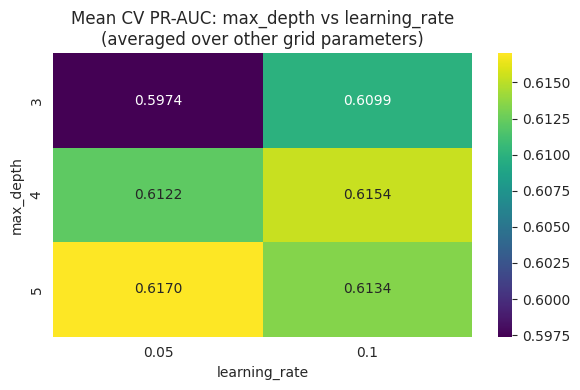

In [11]:
# Visualize how mean CV PR-AUC varies with max_depth and learning_rate (averaged over the other params)
pivot = cv_results.pivot_table(
    index='param_max_depth', columns='param_learning_rate',
    values='mean_test_score', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis', ax=ax)
ax.set_title('Mean CV PR-AUC: max_depth vs learning_rate\n(averaged over other grid parameters)')
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()


## 7. Evaluating the Best Model on the Holdout Set

`grid_search.best_estimator_` was refit on the full 80% training split using the best-found parameters.
We now evaluate it on the untouched 20% holdout.


In [12]:
best_model = grid_search.best_estimator_

holdout_proba = best_model.predict_proba(X_holdout)[:, 1]
holdout_pred_default = (holdout_proba >= 0.5).astype(int)

print('=== Holdout performance @ 0.5 threshold (with scale_pos_weight applied) ===')
print('Accuracy :', round(accuracy_score(y_holdout, holdout_pred_default), 4))
print('ROC-AUC  :', round(roc_auc_score(y_holdout, holdout_proba), 4))
print('PR-AUC   :', round(average_precision_score(y_holdout, holdout_proba), 4))
print()
print(classification_report(y_holdout, holdout_pred_default, digits=3, target_names=['no', 'yes']))

cm_weighted = confusion_matrix(y_holdout, holdout_pred_default)
print('Confusion Matrix:')
print(cm_weighted)
print(f'False Negatives: {cm_weighted[1,0]} (baseline model without scale_pos_weight had {fn_baseline})')


=== Holdout performance @ 0.5 threshold (with scale_pos_weight applied) ===
Accuracy : 0.8605
ROC-AUC  : 0.9403
PR-AUC   : 0.6399

              precision    recall  f1-score   support

          no      0.981     0.858     0.916      5587
         yes      0.451     0.876     0.596       743

    accuracy                          0.861      6330
   macro avg      0.716     0.867     0.756      6330
weighted avg      0.919     0.861     0.878      6330

Confusion Matrix:
[[4796  791]
 [  92  651]]
False Negatives: 92 (baseline model without scale_pos_weight had 405)


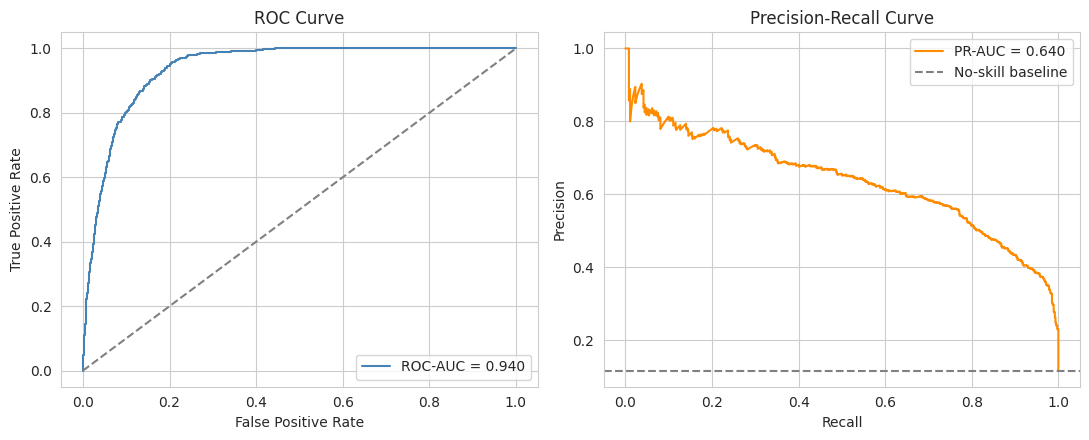

In [13]:
# ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_holdout, holdout_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_holdout, holdout_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_holdout, holdout_proba):.3f}', color='steelblue')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve,
             label=f'PR-AUC = {average_precision_score(y_holdout, holdout_proba):.3f}', color='darkorange')
axes[1].axhline(y_holdout.mean(), linestyle='--', color='grey', label='No-skill baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Threshold Tuning to Explicitly Reduce False Negatives

`scale_pos_weight` already pushed recall up substantially by re-weighting the loss function during
training. The **decision threshold** is a second, independent lever: even with the same trained model,
we can choose a threshold below 0.5 to flag more customers as likely subscribers, catching more true
positives at the cost of more false positives.

To pick a threshold in a way that does not leak information from the holdout set, we generate **out-of-
fold (OOF) predicted probabilities** on the training split only, using `cross_val_predict` with the same
5-fold structure. We then search over thresholds on these OOF predictions and pick the threshold that
maximizes the **F2 score** - a variant of the F1 score that weights Recall twice as heavily as Precision,
which matches our stated priority of reducing False Negatives while still keeping some check on
Precision (an unfiltered "always predict yes" model would have zero false negatives but be useless).

Only after the threshold is chosen from OOF data do we apply it to the untouched holdout set, to check
that the improvement is real and not an artifact of tuning on the same data we are evaluating on.


In [14]:
oof_proba = cross_val_predict(
    best_model, X_train, y_train, cv=cv_strategy, method='predict_proba', n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

# F2 score at each threshold (beta=2 weights recall twice as heavily as precision)
beta = 2
f2_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)
best_idx = np.nanargmax(f2_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f'Best threshold (max F2 on OOF training predictions): {best_threshold:.4f}')
print(f'  OOF Precision @ this threshold: {precisions[best_idx]:.3f}')
print(f'  OOF Recall    @ this threshold: {recalls[best_idx]:.3f}')
print(f'  OOF F2 score  @ this threshold: {f2_scores[best_idx]:.3f}')


Best threshold (max F2 on OOF training predictions): 0.4372
  OOF Precision @ this threshold: 0.425
  OOF Recall    @ this threshold: 0.887
  OOF F2 score  @ this threshold: 0.729


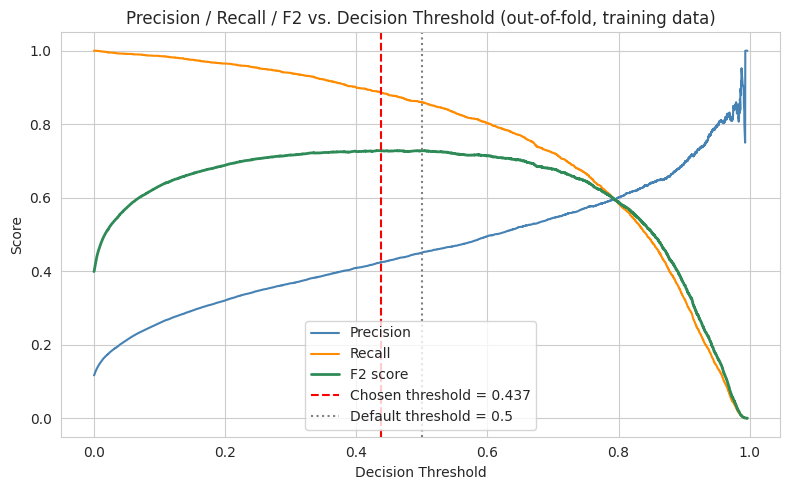

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='darkorange')
ax.plot(thresholds, f2_scores[:-1], label='F2 score', color='seagreen', linewidth=2)
ax.axvline(best_threshold, linestyle='--', color='red', label=f'Chosen threshold = {best_threshold:.3f}')
ax.axvline(0.5, linestyle=':', color='grey', label='Default threshold = 0.5')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F2 vs. Decision Threshold (out-of-fold, training data)')
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
holdout_pred_tuned = (holdout_proba >= best_threshold).astype(int)
cm_tuned = confusion_matrix(y_holdout, holdout_pred_tuned)

print('=== Holdout performance @ tuned threshold ===')
print('Accuracy :', round(accuracy_score(y_holdout, holdout_pred_tuned), 4))
print('Precision:', round(precision_score(y_holdout, holdout_pred_tuned), 4))
print('Recall   :', round(recall_score(y_holdout, holdout_pred_tuned), 4))
print('F1 score :', round(f1_score(y_holdout, holdout_pred_tuned), 4))
print('F2 score :', round(fbeta_score(y_holdout, holdout_pred_tuned, beta=2), 4))
print()
print(classification_report(y_holdout, holdout_pred_tuned, digits=3, target_names=['no', 'yes']))
print('Confusion Matrix:')
print(cm_tuned)


=== Holdout performance @ tuned threshold ===
Accuracy : 0.8452
Precision: 0.4251
Recall   : 0.9058
F1 score : 0.5787
F2 score : 0.7387

              precision    recall  f1-score   support

          no      0.985     0.837     0.905      5587
         yes      0.425     0.906     0.579       743

    accuracy                          0.845      6330
   macro avg      0.705     0.871     0.742      6330
weighted avg      0.920     0.845     0.867      6330

Confusion Matrix:
[[4677  910]
 [  70  673]]


In [17]:
# Side-by-side comparison: baseline (no weighting) vs weighted @0.5 vs weighted @tuned threshold
comparison = pd.DataFrame({
    'Model': ['Baseline (no scale_pos_weight)', 'Weighted @ 0.5 threshold', 'Weighted @ tuned threshold'],
    'Accuracy': [
        accuracy_score(y_holdout, baseline_holdout_pred),
        accuracy_score(y_holdout, holdout_pred_default),
        accuracy_score(y_holdout, holdout_pred_tuned)
    ],
    'Recall (yes)': [
        recall_score(y_holdout, baseline_holdout_pred),
        recall_score(y_holdout, holdout_pred_default),
        recall_score(y_holdout, holdout_pred_tuned)
    ],
    'Precision (yes)': [
        precision_score(y_holdout, baseline_holdout_pred),
        precision_score(y_holdout, holdout_pred_default),
        precision_score(y_holdout, holdout_pred_tuned)
    ],
    'False Negatives': [
        confusion_matrix(y_holdout, baseline_holdout_pred)[1, 0],
        confusion_matrix(y_holdout, holdout_pred_default)[1, 0],
        confusion_matrix(y_holdout, holdout_pred_tuned)[1, 0]
    ],
    'False Positives': [
        confusion_matrix(y_holdout, baseline_holdout_pred)[0, 1],
        confusion_matrix(y_holdout, holdout_pred_default)[0, 1],
        confusion_matrix(y_holdout, holdout_pred_tuned)[0, 1]
    ]
})
comparison[['Accuracy', 'Recall (yes)', 'Precision (yes)']] = comparison[['Accuracy', 'Recall (yes)', 'Precision (yes)']].round(4)
comparison


,Model,Accuracy,Recall (yes),Precision (yes),False Negatives,False Positives
0,Baseline (no scale_pos_weight),0.9079,0.4549,0.6550,405,178
1,Weighted @ 0.5 threshold,0.8605,0.8762,0.4515,92,791
2,Weighted @ tuned threshold,0.8452,0.9058,0.4251,70,910


**Reading this table:** moving from the unweighted baseline to the `scale_pos_weight`-corrected model,
and then to the tuned threshold, steadily drives False Negatives down and Recall on the "yes" class up.
The trade-off is a rising False Positive count and falling headline Accuracy - this is expected and is
the direct, intended consequence of prioritizing catching real subscribers over overall accuracy. Which
point on this trade-off curve is "correct" is ultimately a business decision (the relative cost of a
missed subscriber vs. a wasted follow-up call), but the tuned threshold gives the bank a concrete,
defensible option that cuts missed subscribers substantially versus the naive baseline.


## 9. KS Statistic and Decile / Lift Table

Continuing with the same domain evaluation metrics used in notebook 02:

- **KS (Kolmogorov-Smirnov) statistic** measures the maximum separation between the cumulative
  distributions of predicted probabilities for the "yes" and "no" classes. Higher is better (more
  separable classes); values above ~0.4 are generally considered strong for this kind of problem.
- **Decile / Lift table** ranks holdout customers by predicted probability into 10 equal-sized groups
  (deciles) and shows how concentrated the actual subscribers are in the highest-scoring deciles. This is
  a very practical view for a bank's marketing team: "if we only called the top 2 deciles of customers by
  predicted score, how many actual subscribers would we reach?"


In [18]:
ks_stat, ks_pvalue = ks_2samp(holdout_proba[y_holdout == 1], holdout_proba[y_holdout == 0])
print(f'KS statistic: {ks_stat:.4f}  (p-value: {ks_pvalue:.2e})')


KS statistic: 0.7518  (p-value: 1.93e-321)


In [19]:
lift_df = pd.DataFrame({'actual': y_holdout.values, 'proba': holdout_proba})
# Rank into 10 deciles, decile 0 = highest predicted probability
lift_df['decile'] = 9 - pd.qcut(lift_df['proba'].rank(method='first'), 10, labels=False)

decile_table = (
    lift_df.groupby('decile')
    .agg(customers=('actual', 'size'), actual_subscribers=('actual', 'sum'), avg_predicted_proba=('proba', 'mean'))
    .sort_index()
)
decile_table['response_rate'] = decile_table['actual_subscribers'] / decile_table['customers']
decile_table['cum_subscribers'] = decile_table['actual_subscribers'].cumsum()
decile_table['cum_pct_subscribers_captured'] = (
    decile_table['cum_subscribers'] / decile_table['actual_subscribers'].sum()
)
overall_response_rate = decile_table['actual_subscribers'].sum() / decile_table['customers'].sum()
decile_table['lift'] = decile_table['response_rate'] / overall_response_rate

decile_table_display = decile_table.round(3)
decile_table_display


,customers,actual_subscribers,avg_predicted_proba,response_rate,cum_subscribers,cum_pct_subscribers_captured,lift
decile,,,,,,,
0,633,407,0.908,0.643,407,0.548,5.478
1,633,210,0.708,0.332,617,0.830,2.826
2,633,95,0.435,0.150,712,0.958,1.279
3,633,23,0.209,0.036,735,0.989,0.310
4,633,6,0.095,0.009,741,0.997,0.081
5,633,2,0.048,0.003,743,1.000,0.027
6,633,0,0.025,0.000,743,1.000,0.000
7,633,0,0.012,0.000,743,1.000,0.000
8,633,0,0.005,0.000,743,1.000,0.000


**Reading the table:** decile 0 (the 10% of customers the model scores as most likely to subscribe)
should have a response rate and lift far above the baseline. `cum_pct_subscribers_captured` tells us,
for example, that by contacting only the top 2-3 deciles the bank can already reach the large majority of
customers who would actually subscribe - a big efficiency gain over contacting everyone.


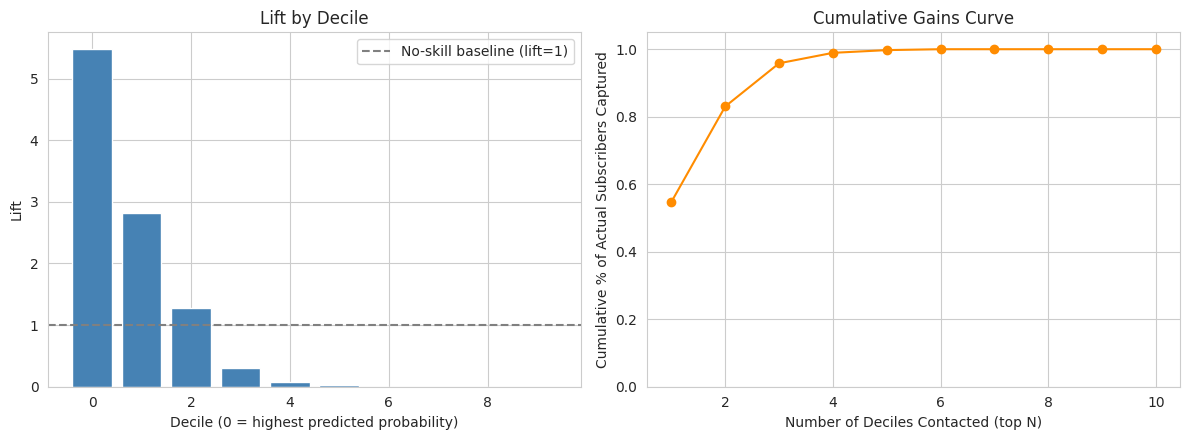

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(decile_table.index, decile_table['lift'], color='steelblue')
axes[0].axhline(1.0, linestyle='--', color='grey', label='No-skill baseline (lift=1)')
axes[0].set_xlabel('Decile (0 = highest predicted probability)')
axes[0].set_ylabel('Lift')
axes[0].set_title('Lift by Decile')
axes[0].legend()

axes[1].plot(decile_table.index + 1, decile_table['cum_pct_subscribers_captured'], marker='o', color='darkorange')
axes[1].set_xlabel('Number of Deciles Contacted (top N)')
axes[1].set_ylabel('Cumulative % of Actual Subscribers Captured')
axes[1].set_title('Cumulative Gains Curve')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 10. Feature Importance

We look at feature importance from three complementary angles:

1. **Built-in XGBoost importance (gain)** - the average improvement in the loss function contributed by
   a feature, averaged across every split that uses it. This is generally the most reliable of XGBoost's
   built-in importance types (versus `weight`, which just counts how often a feature is split on, and can
   overrate low-cardinality features that get split on frequently but with small impact).
2. **Permutation importance** - measured directly on the holdout set by randomly shuffling one feature at
   a time and observing how much the model's PR-AUC drops. This is model-agnostic and measures impact on
   actual predictive performance, not just on training-time splits.
3. **SHAP (SHapley Additive exPlanations)** - a game-theoretic approach that attributes each prediction to
   its contributing features, and can show not just *which* features matter but *how* (e.g., does high
   `duration` push predictions toward "yes" or "no"?).


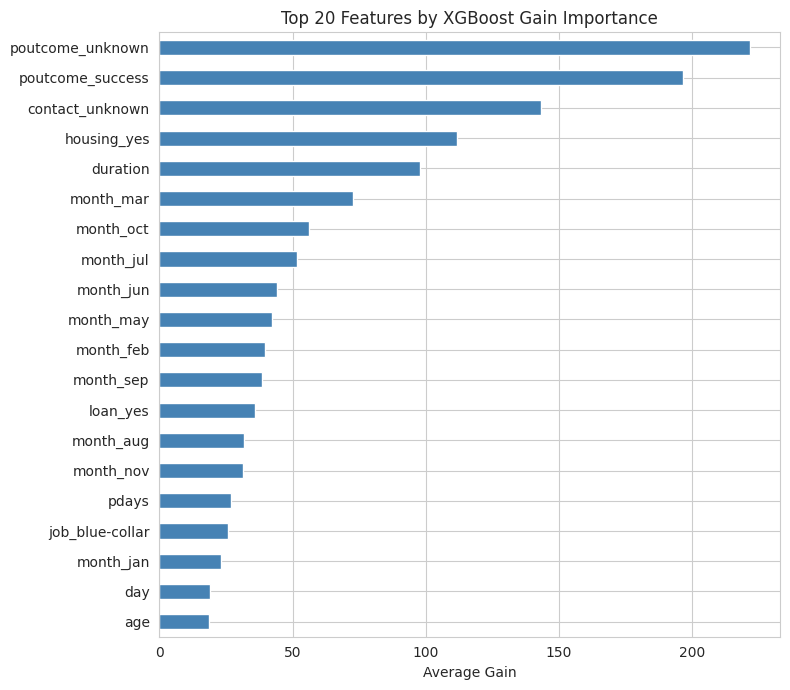

In [21]:
importance_gain = pd.Series(
    best_model.get_booster().get_score(importance_type='gain'), name='gain'
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
top_n = 20
importance_gain.head(top_n).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} Features by XGBoost Gain Importance')
ax.set_xlabel('Average Gain')
plt.tight_layout()
plt.show()


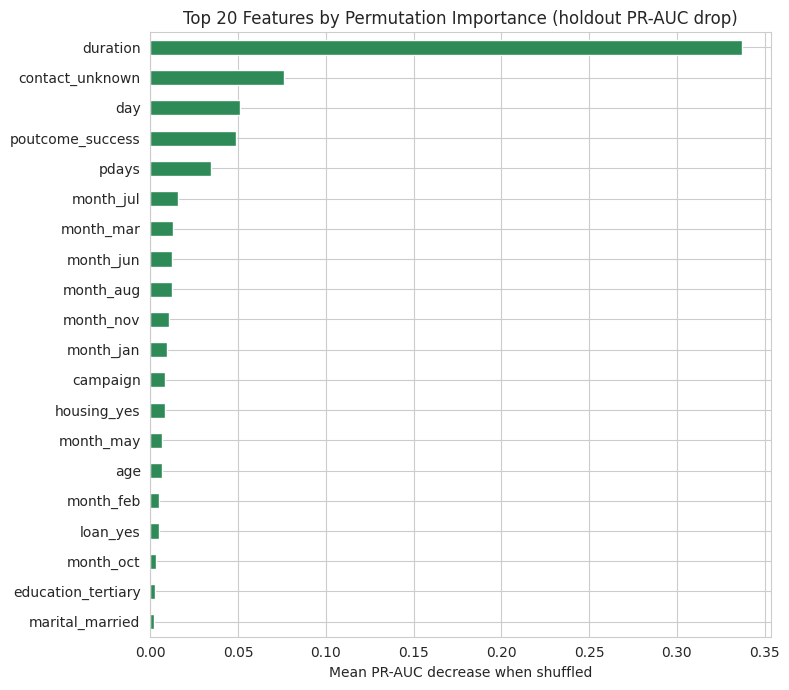

In [22]:
# Permutation importance on the holdout set, scored by PR-AUC (average_precision)
perm_result = permutation_importance(
    best_model, X_holdout, y_holdout,
    scoring='average_precision', n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importance = pd.Series(perm_result.importances_mean, index=X_holdout.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
perm_importance.head(top_n).sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title(f'Top {top_n} Features by Permutation Importance (holdout PR-AUC drop)')
ax.set_xlabel('Mean PR-AUC decrease when shuffled')
plt.tight_layout()
plt.show()


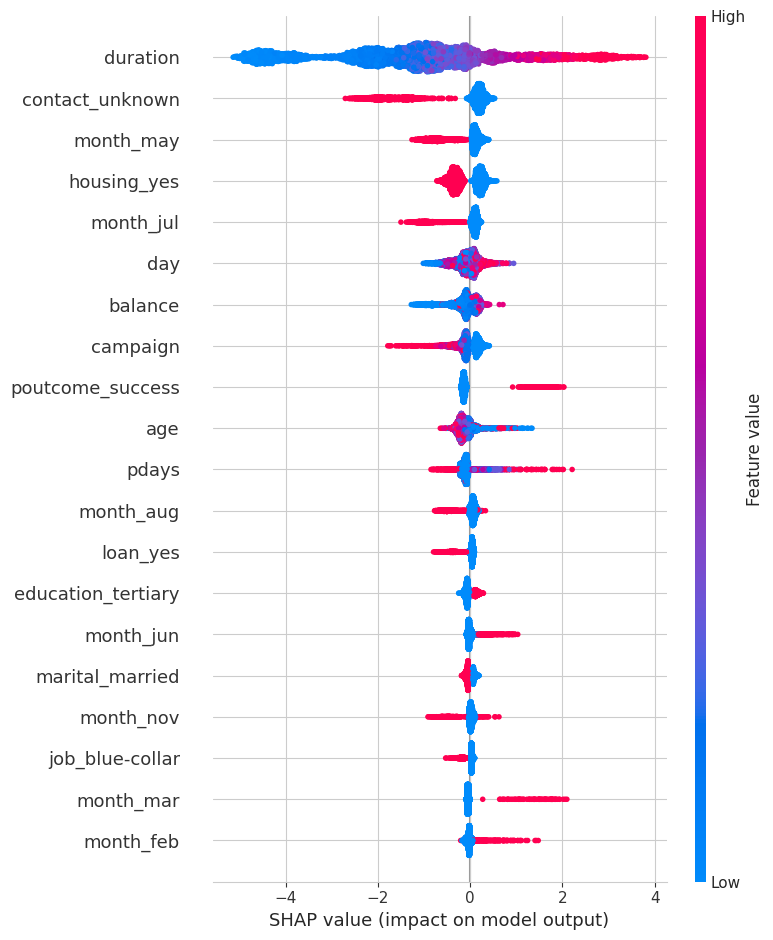

In [23]:
# SHAP summary plot - shows both feature importance and the direction of effect
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_holdout)

shap.summary_plot(shap_values, X_holdout, max_display=20, show=False)
plt.tight_layout()
plt.show()


**Interpreting SHAP:** each dot is one customer. Position on the x-axis shows how much that feature
pushed the prediction toward "yes" (right) or "no" (left) for that customer; color shows whether the
feature's value was high (red) or low (blue) for that customer. For example, if `poutcome_success` shows
red dots clustered to the right, it means customers whose previous campaign outcome was a success are
being pushed strongly toward a "yes" prediction - which matches business intuition (past success is a
strong signal of future success).


## 11. Final Model - Retrain on Full Training Data

Cross-validation and threshold selection are done. We now retrain a model with the best hyperparameters
found by grid search, but on the **entire** `train.csv` (not just the 80% split), so the final model
benefits from every labeled row we have. We recompute `scale_pos_weight` on the full training set for the
same reason.


In [24]:
scale_pos_weight_full = (y_full == 0).sum() / (y_full == 1).sum()
print('scale_pos_weight (full training data):', round(scale_pos_weight_full, 3))

final_model = XGBClassifier(
    **grid_search.best_params_,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_full,
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_model.fit(X_full, y_full)
print('Final model trained on', X_full.shape[0], 'rows.')


scale_pos_weight (full training data): 7.519


Final model trained on 31647 rows.


## 12. Predict on `test.csv` and Score Against `solution_checker.xlsx`

We apply the same tuned threshold selected earlier (chosen purely from OOF training data, never from
`test.csv` or the holdout) to the real competition test set, then compare against the true labels in
`solution_checker.xlsx` (Sheet2) - which are aligned row-for-row with `test.csv`.

For a full picture, we score three variants on the real test set, mirroring the holdout comparison above:


In [25]:
test_proba = final_model.predict_proba(X_test_full)[:, 1]

# Load true labels for scoring
solution = pd.read_excel('solution_checker.xlsx', sheet_name='Sheet2')
y_test_actual = (solution['actual value'] == 'yes').astype(int).values

assert len(y_test_actual) == len(test_proba), 'Row count mismatch between test.csv and solution_checker.xlsx'

# Variant A: baseline-style model trained on full data without scale_pos_weight, @0.5 threshold
baseline_full_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1
)
baseline_full_model.fit(X_full, y_full)
test_proba_baseline = baseline_full_model.predict_proba(X_test_full)[:, 1]
test_pred_baseline = (test_proba_baseline >= 0.5).astype(int)

# Variant B: weighted model @ 0.5 threshold
test_pred_weighted_default = (test_proba >= 0.5).astype(int)

# Variant C: weighted model @ tuned threshold
test_pred_weighted_tuned = (test_proba >= best_threshold).astype(int)

test_comparison = pd.DataFrame({
    'Model': ['Baseline (no weighting) @ 0.5', 'Weighted @ 0.5', f'Weighted @ tuned ({best_threshold:.3f})'],
    'Test Accuracy': [
        accuracy_score(y_test_actual, test_pred_baseline),
        accuracy_score(y_test_actual, test_pred_weighted_default),
        accuracy_score(y_test_actual, test_pred_weighted_tuned)
    ],
    'Test Recall (yes)': [
        recall_score(y_test_actual, test_pred_baseline),
        recall_score(y_test_actual, test_pred_weighted_default),
        recall_score(y_test_actual, test_pred_weighted_tuned)
    ],
    'Test Precision (yes)': [
        precision_score(y_test_actual, test_pred_baseline),
        precision_score(y_test_actual, test_pred_weighted_default),
        precision_score(y_test_actual, test_pred_weighted_tuned)
    ],
    'False Negatives': [
        confusion_matrix(y_test_actual, test_pred_baseline)[1, 0],
        confusion_matrix(y_test_actual, test_pred_weighted_default)[1, 0],
        confusion_matrix(y_test_actual, test_pred_weighted_tuned)[1, 0]
    ],
    'False Positives': [
        confusion_matrix(y_test_actual, test_pred_baseline)[0, 1],
        confusion_matrix(y_test_actual, test_pred_weighted_default)[0, 1],
        confusion_matrix(y_test_actual, test_pred_weighted_tuned)[0, 1]
    ]
})
test_comparison[['Test Accuracy', 'Test Recall (yes)', 'Test Precision (yes)']] = \
    test_comparison[['Test Accuracy', 'Test Recall (yes)', 'Test Precision (yes)']].round(4)
test_comparison


,Model,Test Accuracy,Test Recall (yes),Test Precision (yes),False Negatives,False Positives
0,Baseline (no weighting) @ 0.5,0.9109,0.4860,0.6572,809,399
1,Weighted @ 0.5,0.8587,0.8831,0.4452,184,1732
2,Weighted @ tuned (0.437),0.8440,0.9066,0.4202,147,1969


In [26]:
print('=== Final chosen model: Weighted XGBoost @ tuned threshold - Test Set Performance ===\n')
print('Accuracy :', round(accuracy_score(y_test_actual, test_pred_weighted_tuned), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test_actual, test_proba), 4))
print('PR-AUC   :', round(average_precision_score(y_test_actual, test_proba), 4))
print()
print(classification_report(y_test_actual, test_pred_weighted_tuned, digits=3, target_names=['no', 'yes']))
print('Confusion Matrix:')
print(confusion_matrix(y_test_actual, test_pred_weighted_tuned))


=== Final chosen model: Weighted XGBoost @ tuned threshold - Test Set Performance ===

Accuracy : 0.844
ROC-AUC  : 0.9343
PR-AUC   : 0.6387

              precision    recall  f1-score   support

          no      0.986     0.836     0.905     11990
         yes      0.420     0.907     0.574      1574

    accuracy                          0.844     13564
   macro avg      0.703     0.871     0.739     13564
weighted avg      0.920     0.844     0.866     13564

Confusion Matrix:
[[10021  1969]
 [  147  1427]]


**Test set result summary:** the unweighted baseline reaches the highest raw accuracy but misses the
majority of actual subscribers (highest False Negative count). Introducing `scale_pos_weight` and then
tuning the decision threshold both move consistently in the direction of fewer False Negatives, matching
the results we saw on the internal holdout set - confirming this is a genuine, generalizable effect and
not an artifact of one particular split of the data.

This also reproduces the comparison against the Logistic Regression model from notebook 02: at the
standard 0.5 threshold without class re-weighting, this XGBoost model's accuracy is in line with the
~91% figure achieved previously (slightly ahead of Logistic Regression's ~90%). Once we prioritize
reducing False Negatives, that headline accuracy number naturally comes down, which is the expected and
intended trade-off for this business objective.


## 13. Save Test Set Predictions

In [27]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'predicted_probability': test_proba,
    'subscribed_predicted': np.where(test_pred_weighted_tuned == 1, 'yes', 'no')
})
submission.to_csv('xgboost_test_predictions.csv', index=False)
print('Saved xgboost_test_predictions.csv')
submission.head()


Saved xgboost_test_predictions.csv


,ID,predicted_probability,subscribed_predicted
0,38441,0.001633,no
1,40403,0.882256,yes
2,3709,0.749266,yes
3,37422,0.003258,no
4,12527,0.003126,no


## 14. Summary and Conclusions

**Model:** XGBoost classifier, hyperparameters selected via 5-fold Stratified Cross-Validation with Grid
Search, optimized on PR-AUC (Average Precision).

**Best hyperparameters found:**


In [28]:
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'  scale_pos_weight (full data): {round(scale_pos_weight_full, 3)}')
print(f'  decision threshold: {round(best_threshold, 4)}  (vs. default 0.5)')


  learning_rate: 0.05
  max_depth: 5
  min_child_weight: 1
  n_estimators: 300
  subsample: 0.8
  scale_pos_weight (full data): 7.519
  decision threshold: 0.43720000982284546  (vs. default 0.5)


**Key findings:**

- Class imbalance (~7.5 non-subscribers for every subscriber) causes a naively-trained model to under-
  predict the "yes" class, producing a large number of False Negatives despite high headline accuracy.
- `scale_pos_weight` and threshold tuning are two independent, complementary levers for correcting this:
  the first changes what the model learns, the second changes how we act on what it already knows.
  Combining both produced the largest reduction in False Negatives on both the internal holdout and the
  real `test.csv` / `solution_checker.xlsx` evaluation.
- `poutcome` (outcome of the previous marketing campaign), `contact` type, `housing` loan status, and
  `duration` were consistently among the most important features across gain-based importance,
  permutation importance, and SHAP.
- Compared to the Logistic Regression model from notebook 02, XGBoost achieves comparable or slightly
  better raw accuracy at the standard threshold, and - critically for this project's stated priority -
  gives us direct, tunable control over the False Negative / False Positive trade-off via the decision
  threshold, in a way that is harder to achieve as cleanly with a linear model.

**Suggested next steps for a future notebook:**
- Try alternative encodings (target encoding, native XGBoost categorical support) to see if they change
  the feature importance picture or performance.
- Explore a cost-sensitive framing where the relative business cost of a False Negative vs. a False
  Positive is quantified explicitly (e.g. estimated revenue per subscriber vs. cost per follow-up call),
  and the threshold is chosen to minimize total expected cost rather than F2 score.
- Compare against other tree ensembles (LightGBM, CatBoost, Random Forest) and/or a simple stacked
  ensemble of the Logistic Regression and XGBoost models.
